So the previous notebook I was working on "advancementsims.ipynb" kinda crashed out and so we're starting fresh

In [1]:
using TopographicHorizontalConvection:dissipation_analysis
using TopographicHorizontalConvection:plot_normalized
using TopographicHorizontalConvection:plot_avg
using TopographicHorizontalConvection:diss_norm_eq_subplots
using TopographicHorizontalConvection:get_ψ
using TopographicHorizontalConvection:streamfunction_subplots

In [2]:
using NCDatasets
using CairoMakie
using Printf
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

In [3]:
#oceanostics data

ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/oceanostics.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/oceanostics.nc"));

list_of_datasets = [ds0_o, ds1_o, ds2_o, ds3_o]


#hills

ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

list_hill_datasets = [ds_h0_o, ds_h1_o, ds_h2_o, ds_h3_o];

In [4]:
#buoyancy data

ds0 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/buoyancy.nc"));
ds1 = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_buoyancy.nc"));
ds2 = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/buoyancy.nc"));

list_ds_buoy = [ds0, ds1, ds2, ds3];


ds_h0 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_buoyancy.nc"));
ds_h1 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h2 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds_h3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));

list_hill_ds_buoy = [ds_h0, ds_h1, ds_h2, ds_h3];

In [5]:
#import velocity data 

ds0_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/velocities.nc"));
ds1_v = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_velocities.nc"));
ds2_v = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_velocities.nc"));
ds3_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/velocities.nc"));

list_ds_vel = [ds0_v, ds1_v, ds2_v, ds3_v];


ds_h0_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_velocities.nc"));
ds_h1_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_velocities.nc"));
ds_h2_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_velocities.nc"));
ds_h3_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_velocities.nc"));

list_hill_ds_vel = [ds_h0_v, ds_h1_v, ds_h2_v, ds_h3_v];

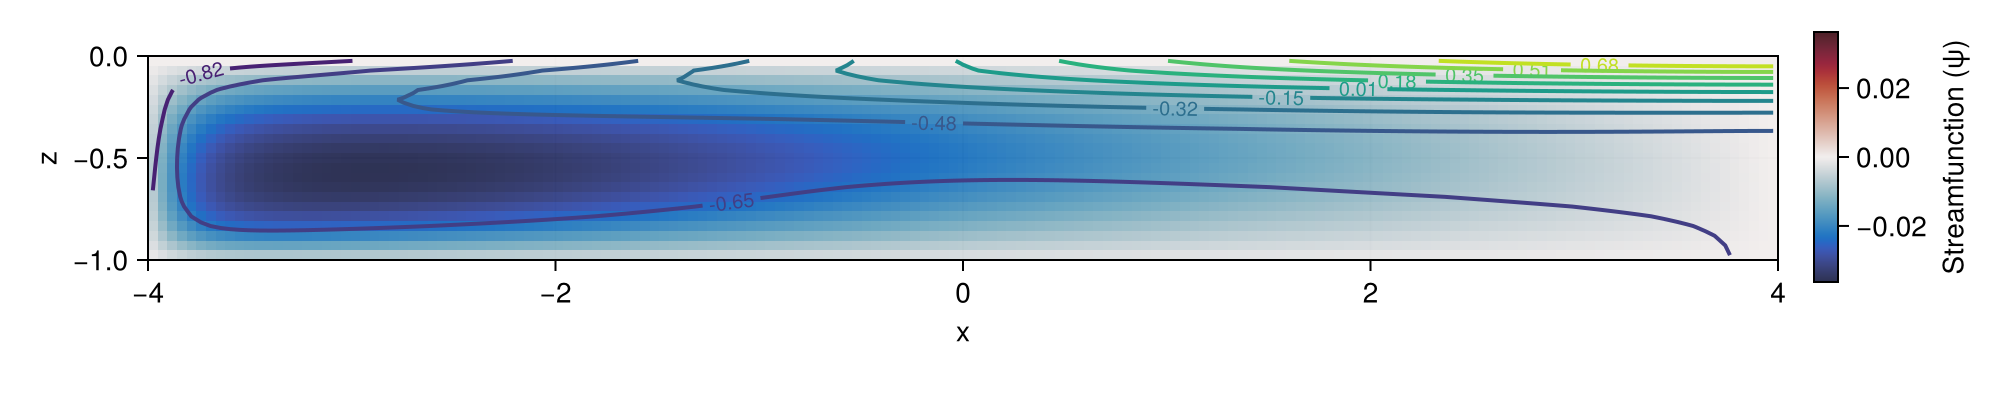

In [28]:
x = ds0_v["xC"][4+1:end-4];
z = ds0_v["zC"][4+1:end-4];
time = ds0_v["time"];
eq_start = round(Int, 0.9 * size(time, 1)); # 90% of the way through the simulation
b_eq = ds0["b"][4+1:end-4, 1, 4+1:end-4, eq_start:end];
wet = b_eq.!= 0; # wet points are those where b_eq is not zero
b_eq[.!wet] .= NaN; # set dry points to NaN
b_avg = nanmean(b_eq, dims=3); #average over time 
b_avg_2d = dropdims(b_avg, dims=(3)); # remove the time dim (which is length 1)

ψ = get_ψ(ds0_v);
ψ_eq = ψ[:, : , eq_start:end]; # get the streamfunction at equilibrium
ψ_avg = nanmean(ψ_eq, dims=3);
ψ_avg_2d = dropdims(ψ_avg, dims=(3));

fig = Figure(size=(1000,200))
ax = Axis(fig, aspect = 8, xlabel = "x", ylabel = "z")
hm = heatmap!(ax, x, z, -ψ_avg_2d, colormap=(:balance, 0.9), colorrange=((-nanmaximum(ψ_avg_2d)), (nanmaximum(ψ_avg_2d))))
contour!(ax, x, z, b_avg_2d, labels=true, levels=10, linewidth=2)
cbar = Colorbar(fig, hm, label = "Streamfunction (ψ)")
fig[1,1] = ax
fig[1,2] = cbar
fig

In [34]:
function streamfunction_subplots(buoy_datasets, vel_datasets; cols=2, main_title="")
    n_datasets = length(buoy_datasets)
    rows = ceil(Int, n_datasets / cols)
    
    fig = Figure(size=(500*cols + 150, 300*rows))
    
    # Add main title if provided
    if !isempty(main_title)
        Label(fig[0, :], main_title, fontsize=20, tellwidth=false)
    end
    
    heatmaps = []  # Store heatmap objects for shared colorbar
    
    for (i, (ds_b, ds_v)) in enumerate(zip(buoy_datasets, vel_datasets))
        row = ceil(Int, i / cols)
        col = ((i - 1) % cols) + 1
        
        # Get spatial coordinates and time
        x = ds_v["xC"][4+1:end-4]
        z = ds_v["zC"][4+1:end-4]
        time = ds_v["time"]
        eq_start = round(Int, 0.9 * size(time, 1))
        
        # Process buoyancy data
        b_eq = ds_b["b"][4+1:end-4, 1, 4+1:end-4, eq_start:end]
        wet = b_eq .!= 0
        b_eq[.!wet] .= NaN
        b_avg = nanmean(b_eq, dims=3)
        b_avg_2d = dropdims(b_avg, dims=(3))

        #create a mask for the wet points
        wet_mask = Float64.(copy(wet))
        wet_mask[wet] .= NaN  # Set wet points to NaN
        
        # Process streamfunction data
        ψ = get_ψ(ds_v)
        ψ_eq = ψ[:, :, eq_start:end]
        ψ_avg = nanmean(ψ_eq, dims=3)
        ψ_avg_2d = dropdims(ψ_avg, dims=(3))
        
        # Get Ra for title
        Ra = ds_b.attrib["Ra"]
        
        # Create subplot
        ax = Axis(fig[row, col], 
                xlabel="x", ylabel="z", 
                title="Ra = $Ra")
        
        # Create heatmap and contour
        hm = heatmap!(ax, x, z, -ψ_avg_2d, 
                     colormap=(:balance, 0.9), 
                     colorrange=((-nanmaximum(ψ_avg_2d)), (nanmaximum(ψ_avg_2d))))
        #plot hills as a different color
        heatmap!(ax, x, z, wet_mask[:,:,1], colormap=:deep)
        contour!(ax, x, z, b_avg_2d, labels=true, levels=10, linewidth=2)
        
        push!(heatmaps, hm)
    end
    
    # Add single colorbar on the right side
    Colorbar(fig[:, end+1], heatmaps[1], label="Streamfunction (ψ)")
    
    return fig
end

streamfunction_subplots (generic function with 1 method)

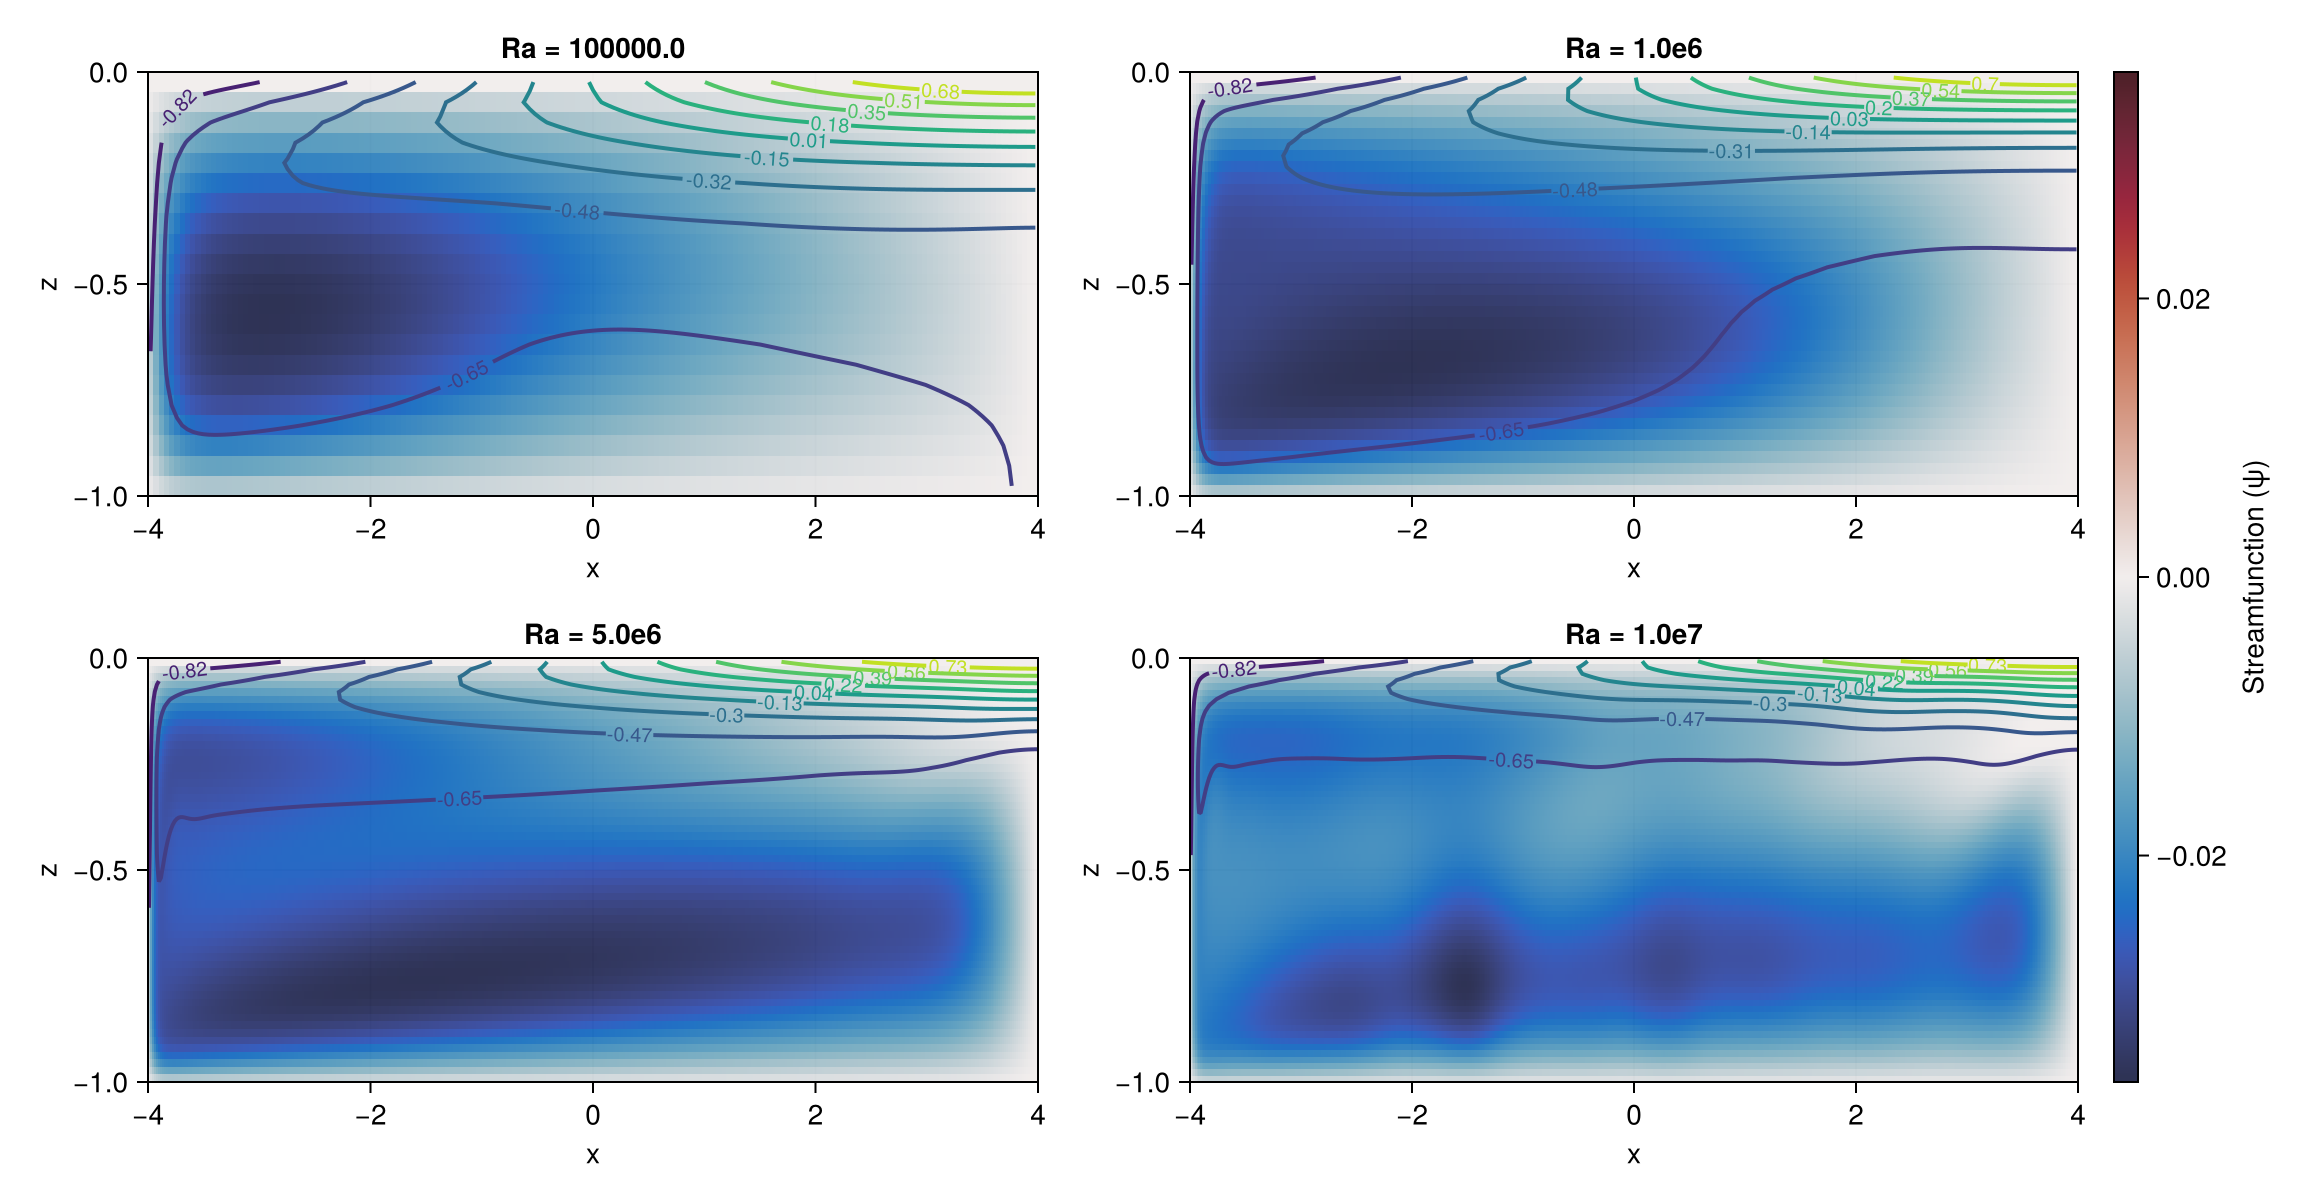

In [6]:
# Create streamfunction subplots for no-hill datasets
fig_no_hills = streamfunction_subplots(list_ds_buoy, list_ds_vel, cols=2)
fig_no_hills

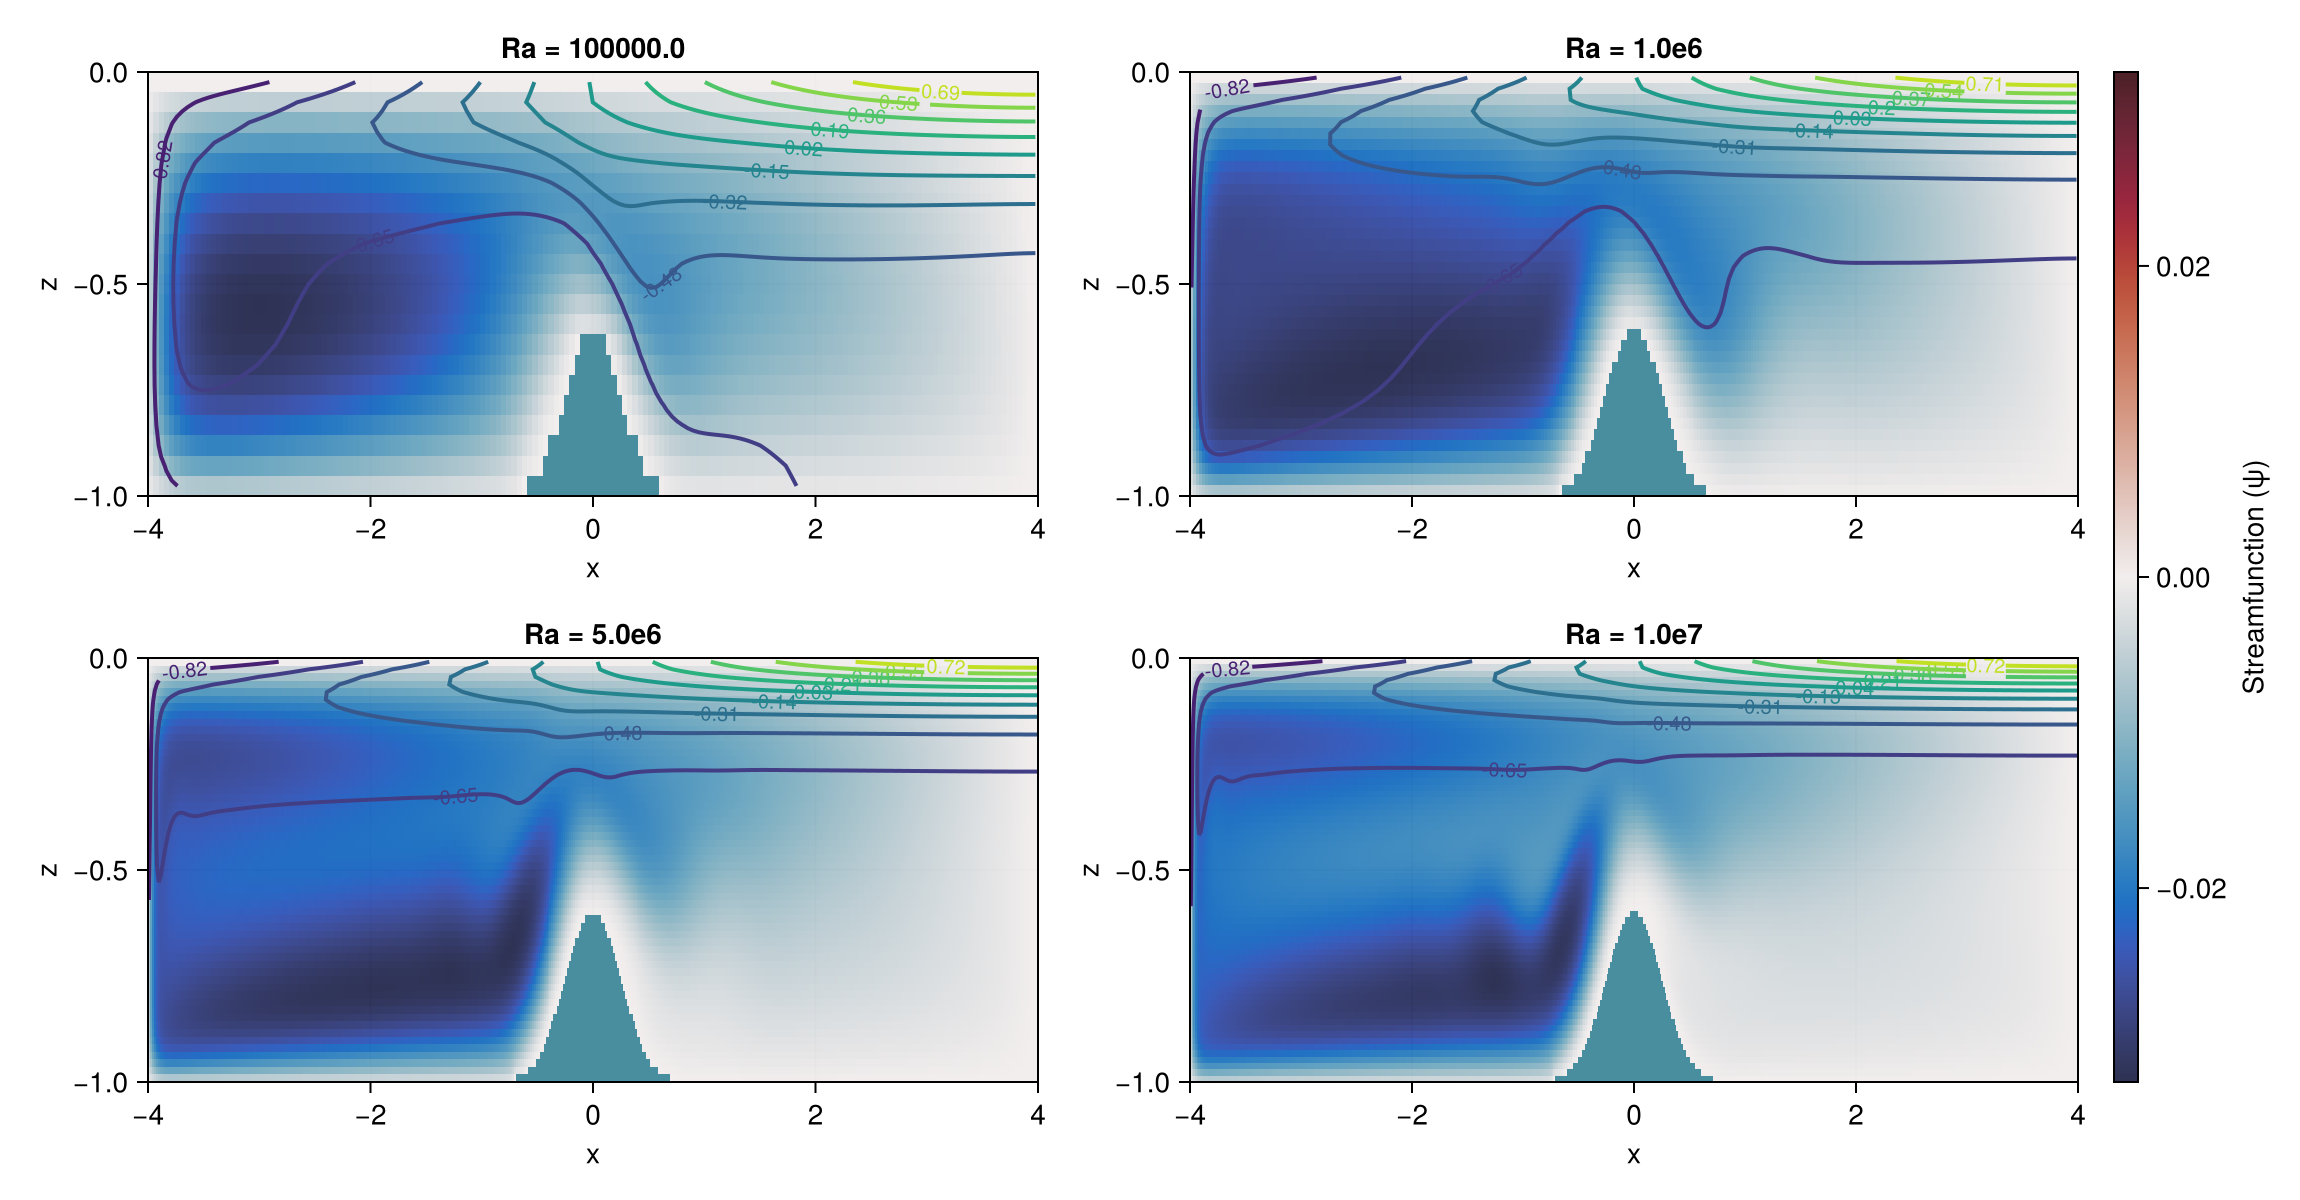

In [7]:
# Create streamfunction subplots for hill datasets
fig_hills = streamfunction_subplots(list_hill_ds_buoy, list_hill_ds_vel, cols=2)
fig_hills